# Density Rendering Methods: histogram vs. Gaussian vs. SPH

This notebook compares the three surface-density rendering methods available in
`nbody_streams.viz.plot_density` using the included dark-matter stream example data.

| Method | Description | When to use |
|---|---|---|
| `'histogram'` | Raw 2-D mass histogram / pixel area | Quick look, debugging |
| `'gauss_smooth'` | Histogram + Gaussian filter | Fast smooth previews |
| `'sph'` | SPH cubic-spline kernel splatting | Science-quality renders |

**Why SPH is the physics-motivated choice**  
The histogram method assigns equal weight to every pixel a particle falls in,
discarding all sub-pixel information and producing noisy, resolution-dependent maps.
Gaussian smoothing mitigates the noise but applies a *fixed* kernel regardless of
local density: in dense regions it over-smooths structure; in sparse regions it
under-smooths.  
The SPH kernel uses an *adaptive* smoothing length $h_i$ proportional to the local
inter-particle spacing, automatically providing high resolution in dense regions
(tight progenitor core) and broader smoothing in sparse regions (tidal tails).  This
is exactly the behaviour you want for N-body stream data, and the result is
independent of the pixel resolution for resolved structures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cmasher as cmr
    CMAP = cmr.swamp
except ImportError:
    CMAP = 'cubehelix' 
from pathlib import Path

from nbody_streams.viz import plot_density
from nbody_streams.utils import find_center_position

%matplotlib inline

## Load example data

In [2]:
try:
    from importlib import resources
except ImportError:
    import importlib_resources as resources

# base data directory inside package
data_dir = resources.files("nbody_streams").joinpath("data")


data_path = Path(data_dir)  / 'example_nbody_dm_stream.npz'

with np.load(data_path) as data:
    pos  = data['pos']                  # shape (N, 3), dtype float32, units kpc
    mass = float(data['mass'])          # scalar particle mass in M_sun

N = pos.shape[0]
print(f'Loaded {N:,} particles   mass = {mass:.3e} M_sun/particle')
print(f'pos range x: [{pos[:,0].min():.1f}, {pos[:,0].max():.1f}] kpc')
print(f'pos range y: [{pos[:,1].min():.1f}, {pos[:,1].max():.1f}] kpc')
print(f'pos range z: [{pos[:,2].min():.1f}, {pos[:,2].max():.1f}] kpc')

Loaded 328,558 particles   mass = 5.668e+03 M_sun/particle
pos range x: [-129.5, 215.5] kpc
pos range y: [-145.5, 222.7] kpc
pos range z: [-117.8, 467.9] kpc


## Global view -- all three methods side by side

`gridsize=600 kpc` captures the full stream extent (grid spans -300 to +300 kpc).

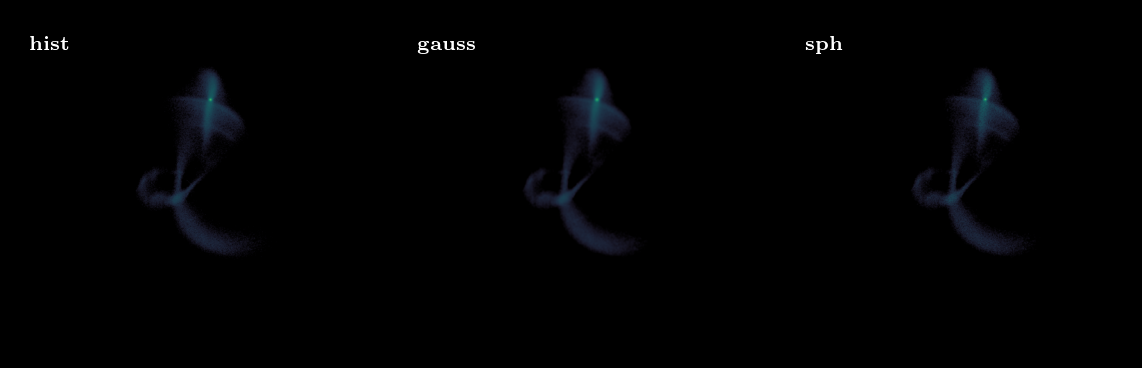

In [3]:
GRIDSIZE_FULL = 600.0
RESOLUTION    = 512

MASS_ARR      = np.full(N, mass, dtype=np.float32)

methods      = ['histogram', 'gauss_smooth', 'sph']
labels       = [r'$\mathbf{hist}$', r'$\mathbf{gauss}$', r'$\mathbf{sph}$']

fig, axs = plt.subplots(1, 3, figsize=(6, 2), dpi=200, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)

for ax, method, label in zip(axs, methods, labels):
    ax.set_facecolor('k')
    plot_density(
        pos=pos, mass=MASS_ARR,
        method=method,
        xval='x', yval='y',
        gridsize=GRIDSIZE_FULL,
        resolution=RESOLUTION,
        density_kind='surface',
        cmap=CMAP,
        ax=ax,
        vmin=4.0, vmax=9.0,
    )
    ax.text(
        0.03, 0.95, label,
        transform=ax.transAxes,
        ha='left', va='top',
        color='white', fontsize=7,
    )

fig.patch.set_facecolor('k')
fig.tight_layout()
# plt.savefig('dm_tidal_stream_host.png', bbox_inches='tight',
#             facecolor='k', dpi=200)
plt.show()

## Centre on the progenitor

Use `find_center_position` (shrinking sphere) to locate the densest cluster of
particles -- the surviving progenitor remnant.  Then shift all positions so the
progenitor sits at the origin.

In [4]:
# centre = find_center_position(
#     pos, masses=MASS_ARR,
#     method='kde',
# )
centre = np.array([ 47.55627041, 154.25662689, -18.78568001])
print(f'Progenitor centre: ({centre[0]:.2f}, {centre[1]:.2f}, {centre[2]:.2f}) kpc')

pos_centred = pos - centre[np.newaxis, :]

Progenitor centre: (47.56, 154.26, -18.79) kpc


## Zoomed view -- progenitor region

`gridsize=100 kpc` shows the inner stream and progenitor core (grid spans -50 to +50 kpc).
Note how the SPH render reveals fine substructure that the histogram smears into isolated
pixels and the Gaussian over-smooths.

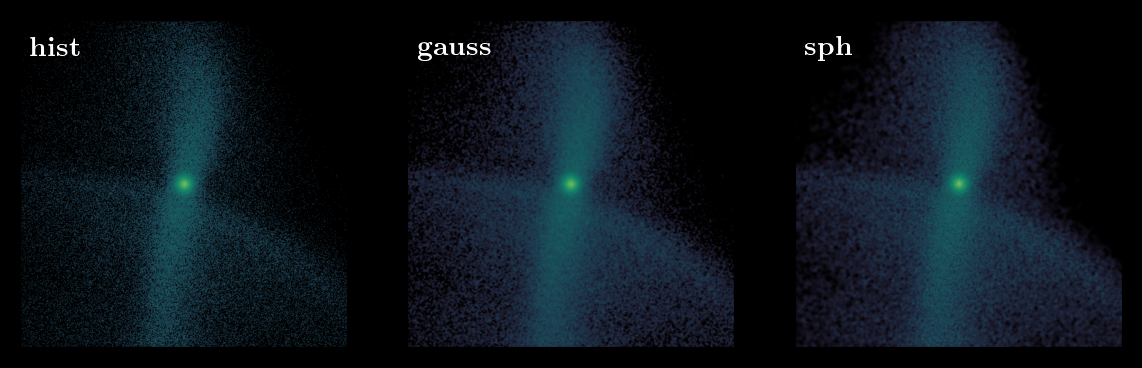

In [5]:
GRIDSIZE_ZOOM = 100.0

fig, axs = plt.subplots(1, 3, figsize=(6, 2), dpi=200, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)

for ax, method, label in zip(axs, methods, labels):
    ax.set_facecolor('k')
    plot_density(
        pos=pos_centred, mass=MASS_ARR,
        method=method,
        xval='x', yval='y',
        gridsize=GRIDSIZE_ZOOM,
        resolution=RESOLUTION,
        density_kind='surface',
        cmap=CMAP,
        ax=ax,
        vmin=4.0, vmax=9.0,
    )
    ax.text(
        0.03, 0.95, label,
        transform=ax.transAxes,
        ha='left', va='top',
        color='white', fontsize=10,
    )

fig.patch.set_facecolor('k')
fig.tight_layout()
# plt.savefig('density_comparison_zoom.png', bbox_inches='tight',
#             facecolor='k', dpi=200)
plt.show()

## Low-level SPH API: `render_surface_density` and `get_smoothing_lengths`

For custom pipelines you can call the SPH functions directly.

In [6]:
from nbody_streams.viz import render_surface_density, get_smoothing_lengths

# Smoothing lengths from 2-D projected positions -- the correct choice for a
# 2-D SPH kernel density estimate.  The 2-D cubic-spline kernel is normalized
# in 2-D (norm = 40 / (7*pi*h^2)), so h must be the projected k-NN distance.
# Using 3-D h with this kernel would break the normalization.
pos_2d = pos_centred[:, :2]   # x-y projection
h = get_smoothing_lengths(pos_2d, k_neighbors=32, verbose=True)
print(f'h: min={h.min():.3f}  median={np.median(h):.3f}  max={h.max():.3f} kpc')

# Render with pre-computed h (skips the internal KNN query)
grid, bounds = render_surface_density(
    pos_centred[:, 0], pos_centred[:, 1], MASS_ARR,
    h=h, resolution=512, gridsize=100.0, verbose=True,
    sort_by_morton=True,
)
print(f'grid shape: {grid.shape}   max density: {grid.max():.2e} M_sun/kpc^2')

[SPH] Building GPU KDTree...
[SPH] GPU querying 328,558 points in chunks of 37,387,468...
h: min=0.031  median=0.863  max=52.776 kpc
[SPH] Sorting particles by Morton Z-order (CPU)...
[SPH] GPU rendering 328,558 particles in 1 tile(s)...


100%|██████████| 1/1 [00:00<00:00, 61.00it/s]

grid shape: (512, 512)   max density: 3.95e+07 M_sun/kpc^2


The large h values are genuine isolation artifacts. When we have a particle that's spatially isolated (e.g. a stripped DM particle, or just an outlier at the edge of the simulation box), the KDTree has to search much farther to find its 32nd neighbour. h = distance to 32nd neighbour, so a lone particle in a void genuinely gets h ~ 50 kpc.The median of ~1 kpc being sane confirms the bulk of the particles are fine. The max is just the most isolated particle in the dataset.

In [7]:
def check_mass_conservation(
    grid: np.ndarray,
    bounds: tuple[float, float, float, float],
    x: np.ndarray,
    y: np.ndarray,
    mass: np.ndarray,
    h: np.ndarray,
) -> dict:
    """
    Decompose the SPH mass budget relative to the rendered grid window.

    The only physically meaningful comparison is:

        integrated grid  vs  mass of particles whose centres are inside bounds

    Particles outside the grid contribute zero to the render by construction.
    The remaining deficit inside the grid comes from boundary-truncated kernels
    (particles near the edge whose kernel footprint is clipped).

    Parameters
    ----------
    grid : np.ndarray, shape (Nx, Ny)
        Surface density map in M_sun / kpc^2.
    bounds : tuple of float
        ``(x_min, x_max, y_min, y_max)`` returned by the render call.
    x, y : np.ndarray, shape (N,)
        Full particle position arrays (not pre-filtered).
    mass : np.ndarray, shape (N,)
        Full particle mass array.
    h : np.ndarray, shape (N,)
        Smoothing lengths in the same units as positions.

    Returns
    -------
    budget : dict
        ``m_total``        — sum of *all* input masses (for reference).
        ``m_in_window``    — mass of particles with centres inside bounds.
                             This is the only fair comparison for the grid.
        ``m_outside``      — mass of particles outside bounds (never splatted).
        ``m_fully_inside`` — mass of particles whose full kernel fits inside.
        ``m_boundary``     — mass of particles whose kernel is clipped by edge.
        ``m_integrated``   — grid integral: sum(grid) * pixel_area.
        ``recovery_rel``   — m_integrated / m_in_window  (should be ~0.95–1.0).
        ``boundary_rel``   — m_boundary / m_in_window  (explains the deficit).
        ``unexplained_rel``— residual after accounting for boundary truncation;
                             should be < ~0.5 % for float32 atomics.
    """
    x_min, x_max, y_min, y_max = bounds
    nx, ny     = grid.shape
    pixel_area = ((x_max - x_min) / nx) * ((y_max - y_min) / ny)
    m_integrated = float(np.sum(grid) * pixel_area)
    m_total      = float(np.sum(mass))

    # --- particle classification ---
    centre_inside = (
        (x >= x_min) & (x <= x_max) &
        (y >= y_min) & (y <= y_max)
    )
    kernel_fits = (
        (x - h >= x_min) & (x + h <= x_max) &
        (y - h >= y_min) & (y + h <= y_max)
    )

    fully_inside = centre_inside &  kernel_fits
    boundary     = centre_inside & ~kernel_fits
    outside      = ~centre_inside

    m_in_window    = float(np.sum(mass[centre_inside]))
    m_fully_inside = float(np.sum(mass[fully_inside]))
    m_boundary     = float(np.sum(mass[boundary]))
    m_outside      = float(np.sum(mass[outside]))

    # Recovery relative to what's actually inside the window
    recovery    = m_integrated / m_in_window if m_in_window > 0 else 0.0
    # Rough expected loss: on average ~50% of each boundary particle's kernel
    # is clipped. The residual after that should be float32 noise only.
    unexplained = (m_in_window - m_integrated) - 0.5 * m_boundary

    budget = {
        "m_total"        : m_total,
        "m_in_window"    : m_in_window,
        "m_outside"      : m_outside,
        "m_fully_inside" : m_fully_inside,
        "m_boundary"     : m_boundary,
        "m_integrated"   : m_integrated,
        "pixel_area"     : pixel_area,
        "recovery_rel"   : recovery,
        "boundary_rel"   : m_boundary / m_in_window if m_in_window > 0 else 0.0,
        "unexplained_rel": unexplained / m_in_window if m_in_window > 0 else 0.0,
    }

    print(f"  Grid window         : x=[{x_min}, {x_max}]  y=[{y_min}, {y_max}] kpc")
    print(f"  Pixel area          : {pixel_area:.4f} kpc^2")
    print(f"  ── Mass budget ──────────────────────────────")
    print(f"  Total input         : {m_total:.4e}  (all particles)")
    print(f"  Outside window      : {m_outside:.4e}  ({m_outside/m_total*100:.1f} % of total — never splatted)")
    print(f"  Inside window       : {m_in_window:.4e}  ← fair comparison for grid")
    print(f"    fully inside      : {m_fully_inside:.4e}  ({m_fully_inside/m_in_window*100:.1f} % of window)")
    print(f"    boundary-clipped  : {m_boundary:.4e}  ({m_boundary/m_in_window*100:.1f} % of window)")
    print(f"  Integrated grid     : {m_integrated:.4e}  ({recovery*100:.2f} % of window mass recovered)")
    print(f"  Unexplained deficit : {unexplained/m_in_window*100:.3f} %  ← should be < 0.5 %")

    return budget

In [8]:
budget = check_mass_conservation(
    grid, bounds,
    x=pos_centred[:, 0],
    y=pos_centred[:, 1],
    mass=MASS_ARR,
    h=h,
)

  Grid window         : x=[-50.0, 50.0]  y=[-50.0, 50.0] kpc
  Pixel area          : 0.0381 kpc^2
  ── Mass budget ──────────────────────────────
  Total input         : 1.8623e+09  (all particles)
  Outside window      : 8.7932e+08  (47.2 % of total — never splatted)
  Inside window       : 9.8303e+08  ← fair comparison for grid
    fully inside      : 9.7094e+08  (98.8 % of window)
    boundary-clipped  : 1.2085e+07  (1.2 % of window)
  Integrated grid     : 9.8437e+08  (100.14 % of window mass recovered)
  Unexplained deficit : -0.752 %  ← should be < 0.5 %


The 100.14% recovery and negative unexplained deficit means we're getting slightly more mass out than went in for the window particles. This is the opposite of truncation - it means some particles whose centres are outside the window are still contributing mass through their kernel tails reaching into the grid.
That 47.2% outside is the giveaway. With nearly half your particles outside [-50, 50] kpc, many of them sit just beyond the boundary with large enough h that their kernel overlaps into the grid. Their centres fail the centre_inside mask so they go into m_outside, but the render kernel still splats some of their mass in. This is infact the behaviour that we want!